<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/My_Live_Handson/Machine_Learning/Boosting_handson_by_me.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Dataset Link:  https://drive.google.com/file/d/1CGnSSp0DHFUD7Et-140y1fkT4IR-M83t/view?usp=sharing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/census-income .csv")

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [ ]:
df.shape

(32561, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
#Handling the ? in the dataset
df.replace("?",np.nan,inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df.isnull().sum().sum()

np.int64(4262)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(23)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Visualize outliers and Label encoding

In [ ]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'annual_income'],
      dtype='object')

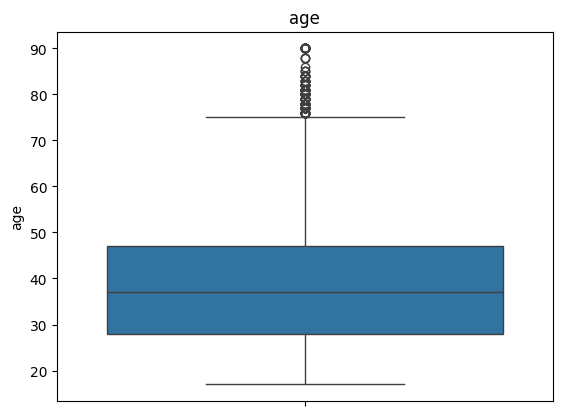

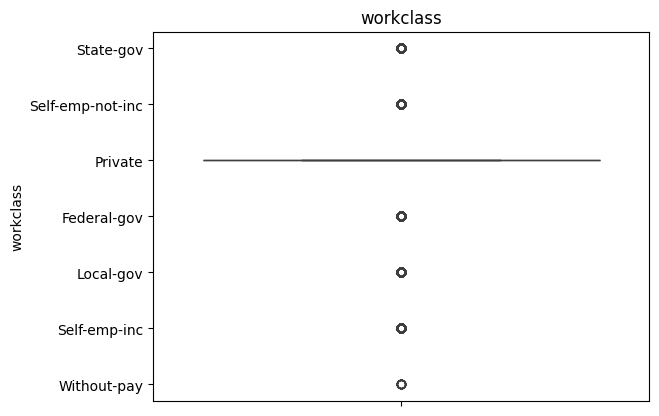

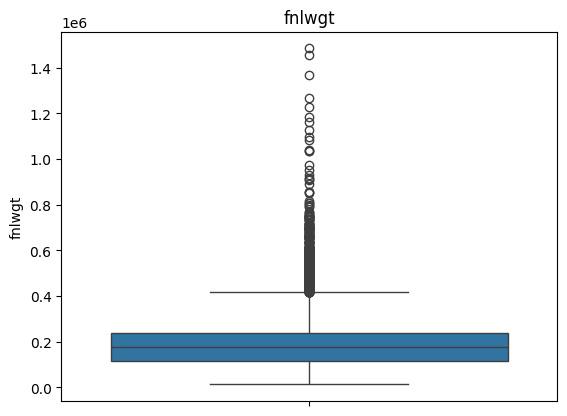

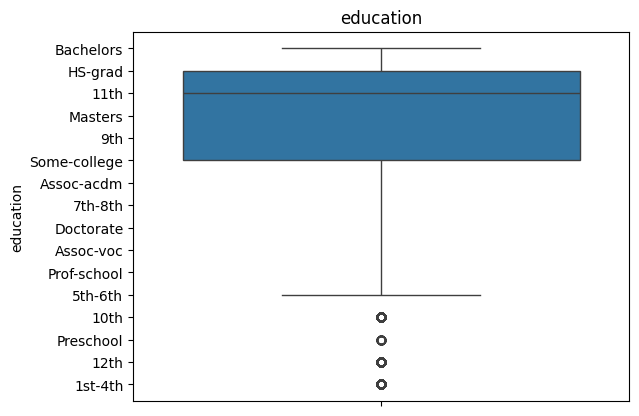

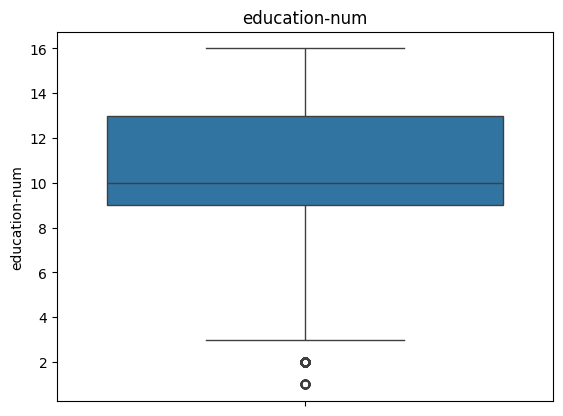

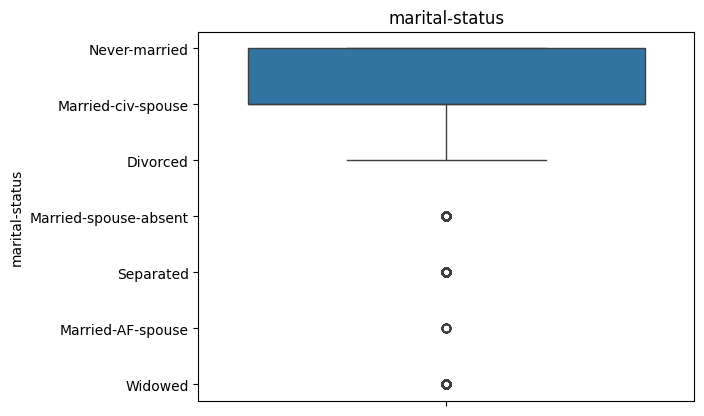

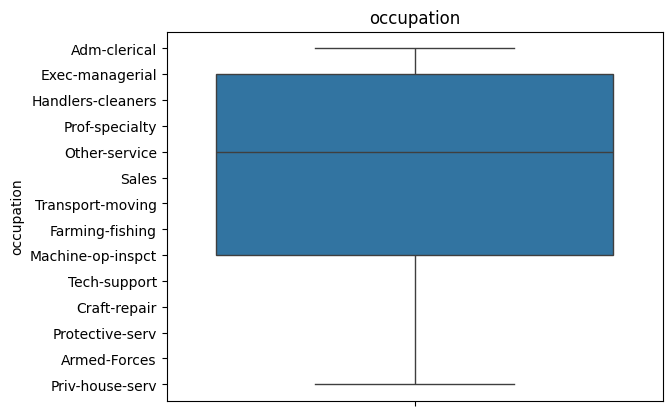

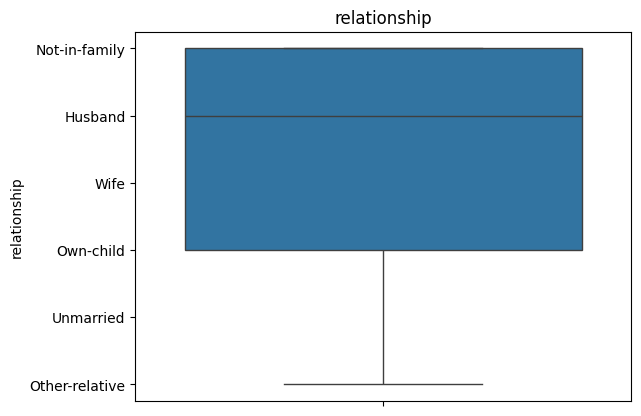

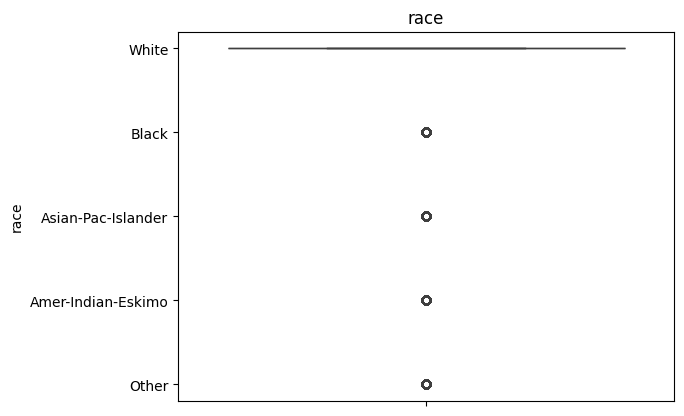

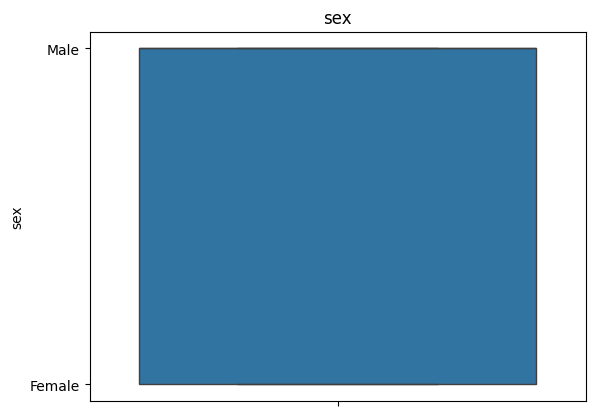

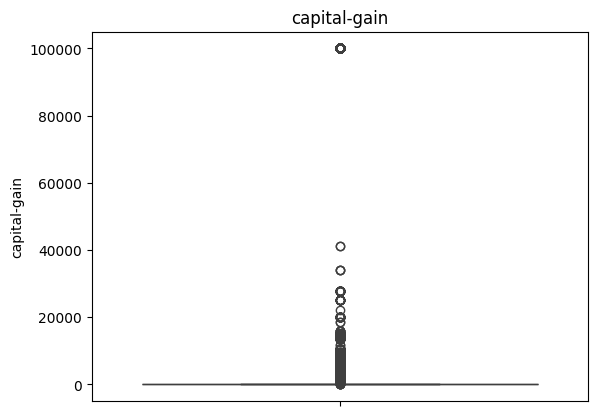

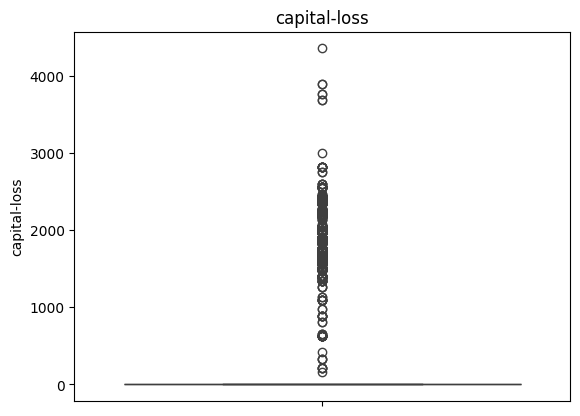

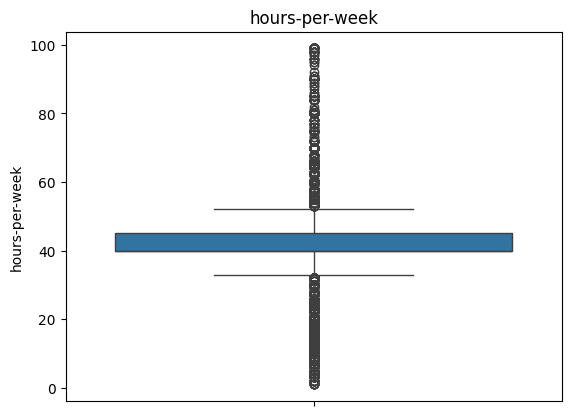

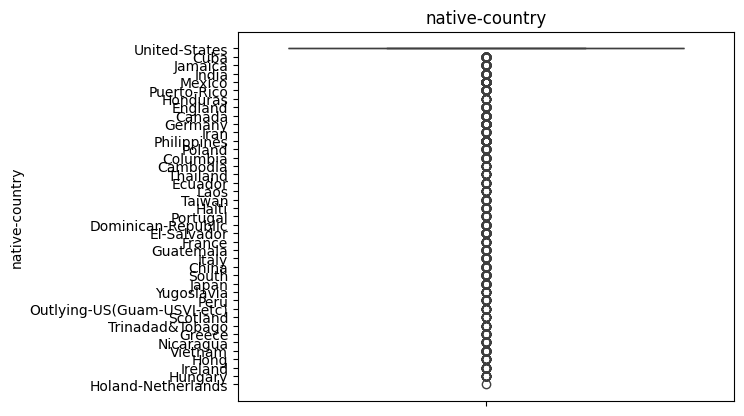

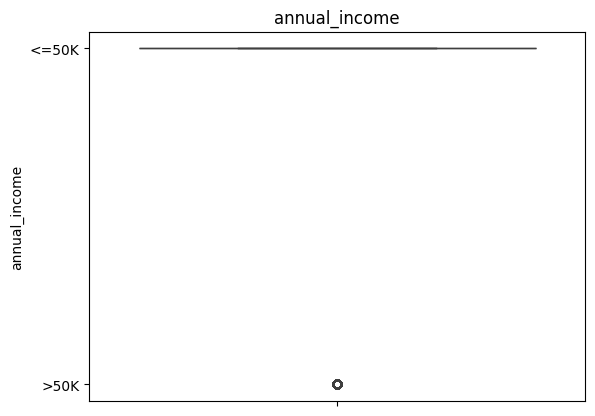

In [ ]:
for col in df.columns:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

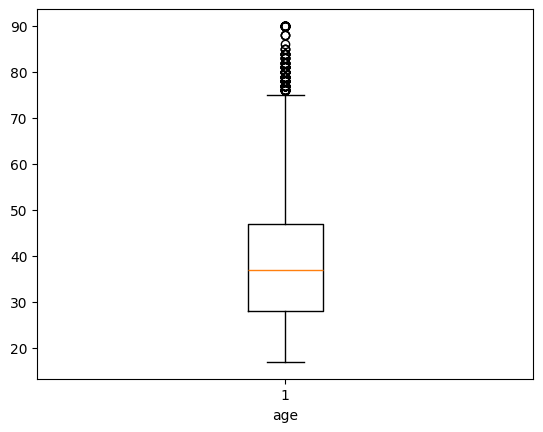

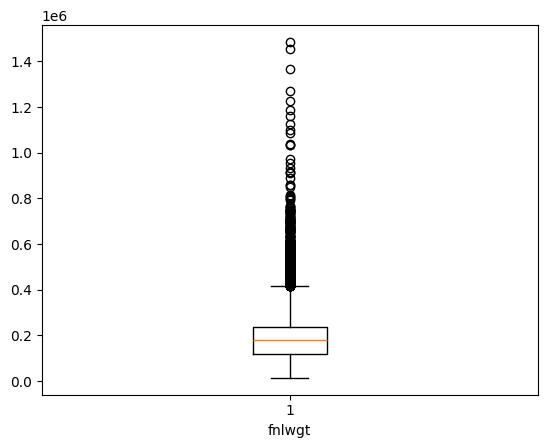

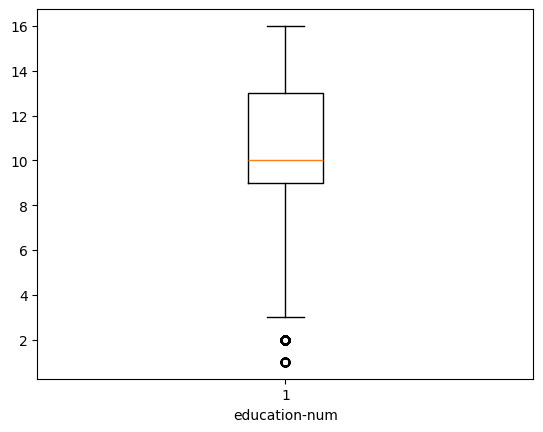

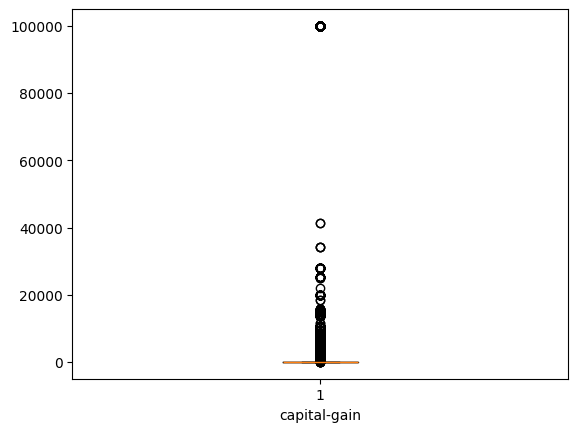

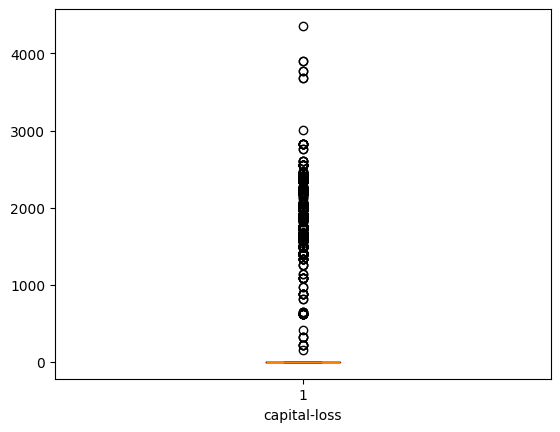

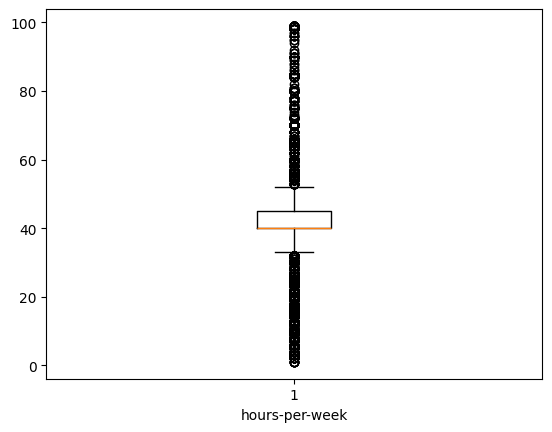

In [ ]:
for col in df.columns:
  if(df[col].dtype != 'object'):
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [23]:
# out_list=['age','fnlwgt','education-num','hours-per-week']

# for col in out_list:
#   Q1=df[col].quantile(0.25)
#   Q3=df[col].quantile(0.75)

#   IQR=Q3-Q1

#   LB=Q1-1.5*(IQR)
#   UB=Q3+1.5*(IQR)

#   df=df[(df[col]>=LB) & (df[col]<=UB)]

In [24]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()
for col in df.columns:
  if(df[col].dtype == 'object'):
    df[col]=LE.fit_transform(df[col])

In [25]:
# train test split

In [27]:
x = df.drop('annual_income', axis=1)

In [28]:
y = df['annual_income']

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [30]:
x_train.shape

(21097, 14)

In [31]:
y_train.shape

(21097,)

In [32]:
x_test.shape

(9042, 14)

In [33]:
x_test.shape

(9042, 14)

In [34]:
# model building

In [35]:
#Logistic Regression, Decision Tree and Random Forest

In [36]:
# Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
lr = LogisticRegression()

In [39]:
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [47]:
y_pred = lr.predict(x_test)

In [41]:
from sklearn.metrics import *

In [48]:
accuracy = accuracy_score(y_test, y_pred)

In [49]:
accuracy

0.7806901128069011

In [44]:
lr2 = LogisticRegression(max_iter=300)

In [45]:
lr2.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=300)

In [50]:
y_pred2 = lr2.predict(x_test)

In [51]:
accuracy2 = accuracy_score(y_test, y_pred2)

In [52]:
accuracy2

0.7967263879672639

In [53]:
lr3 = LogisticRegression(max_iter=1000)

In [54]:
lr3.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [55]:
y_pred3 = lr3.predict(x_test)

In [56]:
accuracy_score(y_test, y_pred3)

0.8056845830568459

In [58]:
confusion_matrix(y_test, y_pred) #model 1

array([[6399,  350],
       [1633,  660]])

In [57]:
# Decision tree

In [59]:
from sklearn.tree import DecisionTreeClassifier

m2=DecisionTreeClassifier()

m2.fit(x_train,y_train)

DecisionTreeClassifier()

In [60]:
y_pred_m2 = m2.predict(x_test)

In [62]:
accuracy_score(y_test, y_pred_m2)

0.8107719531077195

In [63]:
confusion_matrix(y_test, y_pred_m2)

array([[5901,  848],
       [ 863, 1430]])

In [64]:
# random forest

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
rf = RandomForestClassifier()

In [68]:
rf.fit(x_train, y_train)

RandomForestClassifier()

In [69]:
y_pred_rf = rf.predict(x_test)

In [70]:
accuracy_score(y_test, y_pred_rf)

0.85854899358549

In [72]:
confusion_matrix(y_test, y_pred_rf)

array([[6301,  448],
       [ 831, 1462]])

In [ ]:
# Boosting is yet to do